In [53]:
import sys
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Define the path to the 'mapelite' folder
# We assume the notebook is running from the root 'Quality-Diversity-...' folder
mapelite_path = os.path.join(cwd, 'mapelite')

# Add it to the system path so Python can find config.py, utils.py, etc.
if mapelite_path not in sys.path:
    sys.path.append(mapelite_path)
    print(f"Added '{mapelite_path}' to sys.path")

Current Working Directory: d:\dev\Quality-Diversity-for-Racing-Track-Design


In [54]:
import numpy as np
import random
import os

import ribs
from ribs.archives import CVTArchive
from ribs.schedulers import Scheduler
from sklearn.cluster import KMeans

from emitter import CustomEmitter
from mapelite.qd_runner import setup_dask, resume_from_checkpoint, run_qd_loop, plot_stats, export_elites

In [ ]:
from mapelite.config import (
    SOLUTION_DIM,
    BATCH_SIZE,
    BUFFER_DIR,
    CHECKPOINT_DIR,
    STATS_DIR,
    INVALID_SCORE,
    ITERATIONS
)

# --- CVT MAP-Elites specific config ---
checkpoint_dir = CHECKPOINT_DIR + "cvt/"
stats_dir = STATS_DIR
buffer_path = os.path.join(BUFFER_DIR, "cvt.json")
EMBEDDING_DIM = 32
SEED = 67
STATS_FILENAME = "cvt.pkl"
ELITES_OUTPUT = "data/elites/cvt.json"
ALGORITHM_LABEL = "CVT MAP-Elites (CVTArchive + VAE latent descriptors)"

# --- CVT Archive parameters ---
CVT_CELLS = 200          # number of Voronoi regions (centroids) in the archive
CVT_MEASURES = [(-5, 5)] * EMBEDDING_DIM  # bounds per measure dimension (VAE latent space)
PRECOMP_EMBEDDINGS_PATH = "mapelite/embeddings/datasets/embeddings/track_embeddings_metrics_32_mu.npz"

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

In [ ]:
# --- Initialize directories ---
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(stats_dir, exist_ok=True)
os.makedirs(BUFFER_DIR, exist_ok=True)

# --- DASK SETUP ---
client, cluster, evaluator_future = setup_dask(BATCH_SIZE)

Setting up Dask LocalCluster...


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 57725 instead
  warnings.warn(
C:\Users\milob\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (4.93s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


Dask Dashboard link: http://127.0.0.1:57725/status
Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_latent32.pth...
Model loaded with latent_dim=32
Evaluator scattered to 10 Dask workers


In [57]:
# --------------------------------------------------------------
# Resume from latest checkpoint if available,
# otherwise compute CVT centroids and build archive from scratch
# --------------------------------------------------------------
state = resume_from_checkpoint(checkpoint_dir, stats_dir, STATS_FILENAME)
start_iter        = state["start_iter"]
global_best_score = state["global_best_score"]
global_best_id    = state["global_best_id"]
stats             = state["stats"]

if state["scheduler"] is not None:
    scheduler = state["scheduler"]
    archive   = state["archive"]
else:
    print("Computing CVT centroids...")
    embeddings_data = np.load(PRECOMP_EMBEDDINGS_PATH)["embeddings"]
    print(f"Loaded {embeddings_data.shape[0]} embeddings ({embeddings_data.shape[1]}D) from {PRECOMP_EMBEDDINGS_PATH}")

    km = KMeans(n_clusters=CVT_CELLS, random_state=SEED, n_init=10)
    km.fit(embeddings_data)
    custom_centroids = km.cluster_centers_
    print(f"Computed {custom_centroids.shape[0]} centroids via k-means")

    archive = CVTArchive(
        solution_dim=SOLUTION_DIM,
        ranges=CVT_MEASURES,
        cells=CVT_CELLS,
        seed=SEED,
        custom_centroids=custom_centroids,
    )

    emitter = CustomEmitter(
        archive,
        solution_dim=SOLUTION_DIM,
        batch_size=BATCH_SIZE,
        bounds=[(0, 600)] * (SOLUTION_DIM - 1) + [(0, float("inf"))]
    )

    scheduler = Scheduler(archive, [emitter])
    print("Archive, emitter, and scheduler created.")

[Resume] Loaded data/checkpoints/cvt\checkpoint_0350.pkl, resuming from iteration 351
[Resume] Resumed stats with 350 entries


In [58]:
# # --- Pilot: measure pairwise distances in embedding space ---
# from scipy.spatial.distance import pdist

# PILOT_ITERS = 5  # number of batches to sample
# pilot_measures = []

# for _ in range(PILOT_ITERS):
#     sols = scheduler.ask()
#     sol_dicts = [array_to_solution(sol) for sol in sols]

#     futs = [client.submit(_eval_on_worker, evaluator_future, sol) for sol in sol_dicts]
#     gathered = [f.result() for f in as_completed(futs)]

#     for sol_id, ok, msg, score, desc in gathered:
#         if ok:
#             pilot_measures.append(desc)

#     # Still need to tell the scheduler so it doesn't break
#     objs, descs = zip(*[(score if ok else INVALID_SCORE, desc)
#                         for sol_id, ok, msg, score, desc in gathered])
#     scheduler.tell(list(objs), list(descs))

# pilot_measures = np.array(pilot_measures)
# dists = pdist(pilot_measures)

# print(f"Pilot: {len(pilot_measures)} valid embeddings collected")
# print(f"Pairwise distances — min={dists.min():.4f}, "
#       f"25th={np.percentile(dists, 25):.4f}, "
#       f"median={np.median(dists):.4f}, "
#       f"75th={np.percentile(dists, 75):.4f}, "
#       f"max={dists.max():.4f}, "
#       f"mean={dists.mean():.4f}")
# print(f"\nSuggested novelty_threshold range: {np.percentile(dists, 10):.4f} – {np.median(dists) * 0.5:.4f}")

In [ ]:
# Run main loop
global_best_score, global_best_id, stats = run_qd_loop(
    scheduler=scheduler,
    archive=archive,
    client=client,
    evaluator_future=evaluator_future,
    total_iters=ITERATIONS,
    start_iter=start_iter,
    checkpoint_dir=checkpoint_dir,
    stats_dir=stats_dir,
    stats_filename=STATS_FILENAME,
    stats=stats,
    global_best_score=global_best_score,
    global_best_id=global_best_id,
    buffer_path=buffer_path,
)

Emitter.ask() called for iteration 351
Mutating solutions for iteration 351
Solution ID=350.09551823505166 evaluated with score=7.75
Solution ID=350.30821956876133 evaluated with score=22.75
Solution ID=350.40070243737114 evaluated with score=3.25
Solution ID=350.8816498189519 evaluated with score=17.50
Solution ID=350.6499313900366 evaluated with score=18.50
Solution ID=350.90729577006425 evaluated with score=6.25
Solution ID=350.7334925063314 evaluated with score=14.00
Solution ID=350.1605861333915 evaluated with score=16.50
Solution ID=350.15271935592233 evaluated with score=26.50
Iteration 351 ended. Best in batch = 26.50
Global best so far: 44.00 (ID=90.74493813932156)
Archive Updates: 0 new elites inserted, 0 elites substituted.
Archive size=200, mean=25.42, best=44.00
Emitter.ask() called for iteration 352
Crossover solutions for iteration 352
Solution ID=351.4421544473587 evaluated with score=8.50
Solution ID=351.2358207034023 evaluated with score=6.25
Solution ID=351.136677627

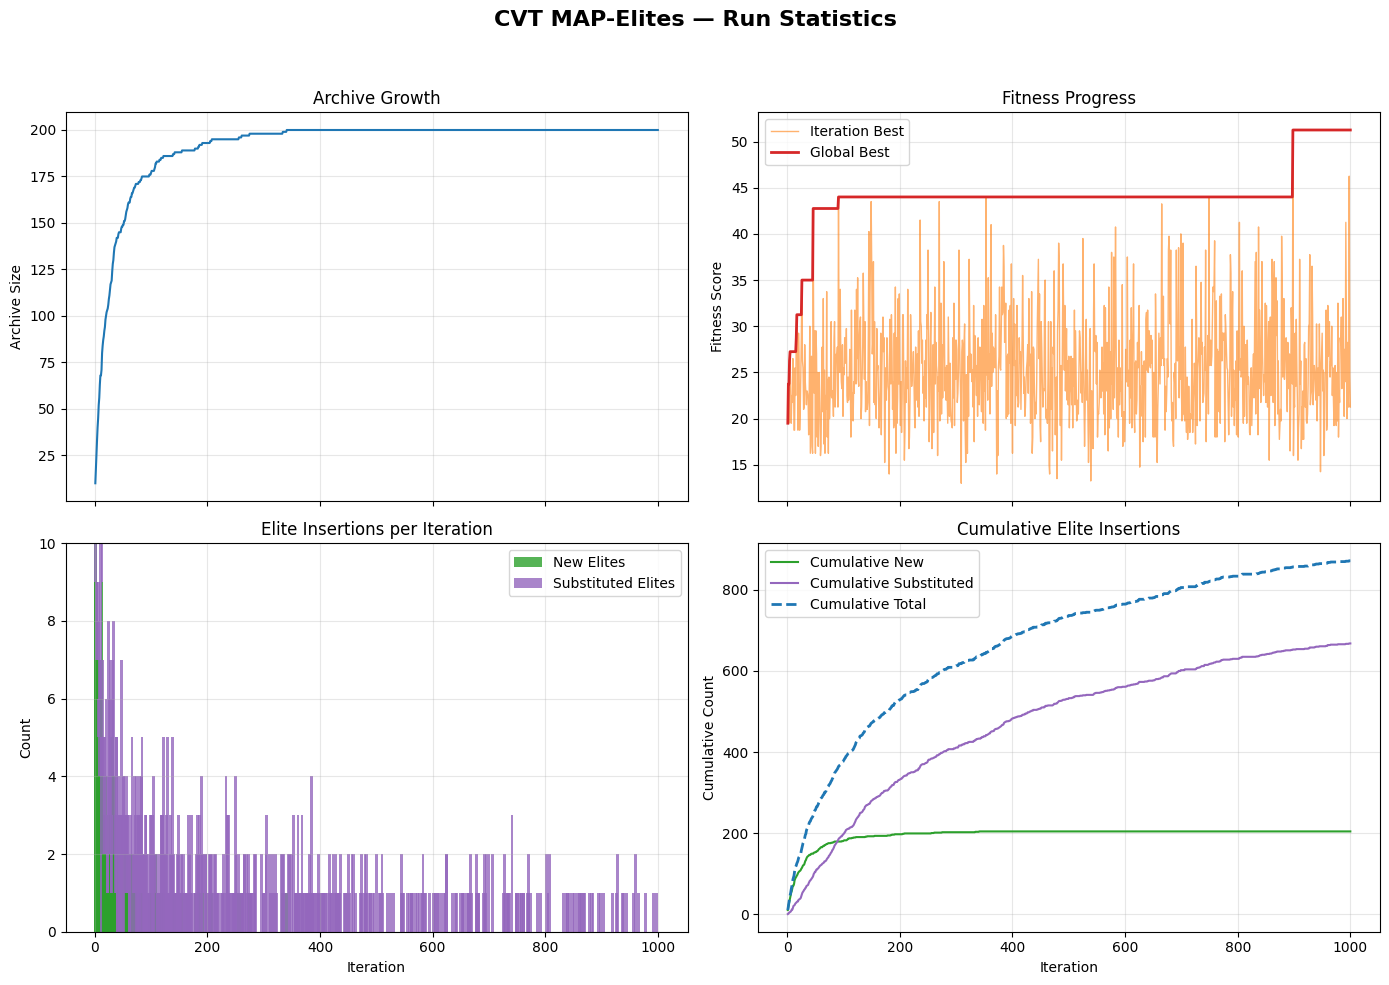


  CVT MAP-Elites Summary
  Total iterations:        1000
  Final archive size:      200
  Global best fitness:     51.2500
  Total new elites:        204
  Total substituted:       668
  Avg new elites/iter:     0.20
  Avg substituted/iter:    0.67


In [60]:
plot_stats(stats, title="CVT MAP-Elites")

In [61]:
export_elites(
    archive=archive,
    stats=stats,
    output_path=ELITES_OUTPUT,
    algorithm_label=ALGORITHM_LABEL,
    seed=SEED,
    global_best_score=global_best_score,
    global_best_id=global_best_id,
)

Saved 200 elites to data/elites/cvt.json
  Best fitness:  51.2500 (ID=897.1698478772297)
  Worst fitness: 10.2500
  File size:     2164.1 KB
